# 02 — WESAD Preprocessing Pipeline
**Project:** Quantum Machine Learning for Physiological Stress Classification: A Comparative Study of QSVM and VQC on WESAD  
**Author:** Kenza Qribis

---

## Purpose
Build the full preprocessing pipeline that transforms raw WESAD signals into a clean, model-ready feature matrix. All design decisions made in notebook 01 are applied here.

## Pipeline Steps
1. Load each subject's raw signals
2. Segment into 60s windows (50% overlap), discard transition windows (<80% label purity)
3. Extract hand-crafted features per window per modality (ECG, EDA, Resp, Temp, ACC)
4. Assemble feature matrix with subject IDs and labels
5. Produce binary dataset (baseline vs stress) and 3-class dataset (+ amusement)
6. Save LOSO-ready datasets to `results/output_data/`

## Important: No Data Leakage
Normalization (StandardScaler) and PCA are fitted **per LOSO fold** inside the modeling notebooks — NOT here. This notebook only extracts raw features and saves them. Scaling happens at training time.

---
> Set `WESAD_PATH` in Section 0 before running.

## 0. Configuration

In [1]:
import os
import pickle
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datetime import datetime
from scipy import signal as scipy_signal
from scipy.stats import skew, kurtosis
import neurokit2 as nk

warnings.filterwarnings('ignore')

# ── SET THIS ──────────────────────────────────────────────────────────────────
WESAD_PATH = r"C:/Users/ACER/Desktop/APPLIED RESEARCH/Applied-Research/data/WESAD" 
# ─────────────────────────────────────────────────────────────────────────────

# ── Results folders ───────────────────────────────────────────────────────────
RESULTS_ROOT    = os.path.join("..", "results")
PLOTS_DIR       = os.path.join(RESULTS_ROOT, "plots", "02_preprocessing")
LOGS_DIR        = os.path.join(RESULTS_ROOT, "logs")
OUTPUT_DATA_DIR = os.path.join(RESULTS_ROOT, "output_data")
for d in [PLOTS_DIR, LOGS_DIR, OUTPUT_DATA_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Subjects ──────────────────────────────────────────────────────────────────
ALL_SUBJECTS = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]

# ── Labels ────────────────────────────────────────────────────────────────────
LABEL_MAP = {0:'not_defined', 1:'baseline', 2:'stress', 3:'amusement', 4:'meditation'}
BINARY_MAP    = {1: 0, 2: 1}            # baseline=0, stress=1
THREE_CLS_MAP = {1: 0, 2: 1, 3: 2}     # baseline=0, stress=1, amusement=2

# ── Sampling rates ────────────────────────────────────────────────────────────
FS = 700   # all chest signals at 700 Hz

# ── Windowing ─────────────────────────────────────────────────────────────────
WINDOW_S  = 60      # window length in seconds
STEP_S    = 30      # step size in seconds (50% overlap)
PURITY    = 0.80    # minimum label purity to keep a window
WIN_SAMP  = WINDOW_S * FS   # samples per window
STEP_SAMP = STEP_S  * FS    # samples per step

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

print('Configuration ready.')
print(f'  Window : {WINDOW_S}s ({WIN_SAMP:,} samples)')
print(f'  Step   : {STEP_S}s  ({STEP_SAMP:,} samples)')
print(f'  Purity : {PURITY*100:.0f}%')

Configuration ready.
  Window : 60s (42,000 samples)
  Step   : 30s  (21,000 samples)
  Purity : 80%


## 1. Signal Loading

In [2]:
def load_subject(wesad_path, subject_id):
    pkl = os.path.join(wesad_path, f'S{subject_id}', f'S{subject_id}.pkl')
    with open(pkl, 'rb') as f:
        return pickle.load(f, encoding='latin1')

# Quick load test
test = load_subject(WESAD_PATH, 2)
print('Load test passed.')
print(f'Chest signals : {list(test["signal"]["chest"].keys())}')
print(f'Wrist signals : {list(test["signal"]["wrist"].keys())}')

Load test passed.
Chest signals : ['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']
Wrist signals : ['ACC', 'BVP', 'EDA', 'TEMP']


## 2. Signal Preprocessing (per modality)

In [7]:
# ── Bandpass filter for ECG ───────────────────────────────────────────────────
def bandpass_filter(sig, lowcut=0.5, highcut=40.0, fs=700, order=4):
    """Butterworth bandpass filter — standard for ECG."""
    nyq = fs / 2
    b, a = scipy_signal.butter(order,
                                [lowcut/nyq, highcut/nyq],
                                btype='band')
    return scipy_signal.filtfilt(b, a, sig)


def lowpass_filter(sig, cutoff=1.0, fs=700, order=4):
    """Butterworth lowpass — used for EDA."""
    nyq = fs / 2
    b, a = scipy_signal.butter(order, cutoff/nyq, btype='low')
    return scipy_signal.filtfilt(b, a, sig)


def preprocess_chest_signals(chest):
    processed = {}

    # ECG — bandpass 0.5–40 Hz
    ecg_raw = np.array(chest['ECG']).flatten()
    processed['ECG'] = bandpass_filter(ecg_raw, 0.5, 40.0, FS)

    # EDA — lowpass 1 Hz
    eda_raw = np.array(chest['EDA']).flatten()
    processed['EDA'] = lowpass_filter(eda_raw, 1.0, FS)

    # EMG — bandpass 20–340 Hz (capped below Nyquist of 350 Hz)
    if 'EMG' in chest:
        emg_raw = np.array(chest['EMG']).flatten()
        processed['EMG'] = bandpass_filter(emg_raw, 20.0, 340.0, FS)

    # Respiration — bandpass 0.1–0.5 Hz
    resp_raw = np.array(chest['Resp']).flatten()
    processed['Resp'] = bandpass_filter(resp_raw, 0.1, 0.5, FS)

    # Temperature — no filter needed
    processed['Temp'] = np.array(chest['Temp']).flatten()

    # ACC — magnitude
    acc_raw = np.array(chest['ACC'])
    processed['ACC'] = np.linalg.norm(acc_raw, axis=1)

    return processed


print('Signal preprocessing functions defined.')

Signal preprocessing functions defined.


## 3. Feature Extraction Functions

In [8]:
# ── ECG / HRV features ────────────────────────────────────────────────────────
def extract_ecg_features(ecg_window, fs=700):
    """
    Extract HRV features from a single ECG window using NeuroKit2.
    Returns dict of features. Falls back to NaN on failure.
    """
    try:
        _, info = nk.ecg_process(ecg_window, sampling_rate=fs)
        hrv    = nk.hrv_time(info['ECG_R_Peaks'], sampling_rate=fs, show=False)

        # Mean heart rate from R-peaks
        rpeaks = info['ECG_R_Peaks']
        if len(rpeaks) < 2:
            raise ValueError('Too few R-peaks')
        rr_intervals = np.diff(rpeaks) / fs * 1000  # ms
        mean_hr = 60000 / np.mean(rr_intervals)

        return {
            'ecg_mean_hr'  : mean_hr,
            'ecg_sdnn'     : float(hrv['HRV_SDNN'].iloc[0]),
            'ecg_rmssd'    : float(hrv['HRV_RMSSD'].iloc[0]),
            'ecg_pnn50'    : float(hrv['HRV_pNN50'].iloc[0]),
            'ecg_mean_rr'  : float(np.mean(rr_intervals)),
            'ecg_std_rr'   : float(np.std(rr_intervals)),
        }
    except Exception:
        return {k: np.nan for k in
                ['ecg_mean_hr','ecg_sdnn','ecg_rmssd',
                 'ecg_pnn50','ecg_mean_rr','ecg_std_rr']}


# ── EDA features ──────────────────────────────────────────────────────────────
def extract_eda_features(eda_window, fs=700):
    """
    Extract EDA features: SCL statistics and SCR peaks.
    """
    try:
        eda_signals, _ = nk.eda_process(eda_window, sampling_rate=fs)
        scl = eda_signals['EDA_Tonic'].values
        scr = eda_signals['EDA_Phasic'].values

        # SCR peaks
        peaks, _ = scipy_signal.find_peaks(scr,
                                            height=0.01,
                                            distance=fs//2)
        scr_amp = scr[peaks].mean() if len(peaks) > 0 else 0.0

        return {
            'eda_mean_scl'    : float(np.mean(scl)),
            'eda_std_scl'     : float(np.std(scl)),
            'eda_mean_raw'    : float(np.mean(eda_window)),
            'eda_n_scr_peaks' : int(len(peaks)),
            'eda_mean_scr_amp': float(scr_amp),
        }
    except Exception:
        return {k: np.nan for k in
                ['eda_mean_scl','eda_std_scl','eda_mean_raw',
                 'eda_n_scr_peaks','eda_mean_scr_amp']}


# ── Respiration features ──────────────────────────────────────────────────────
def extract_resp_features(resp_window, fs=700):
    """
    Extract breathing rate, amplitude, and variability.
    """
    try:
        rsp_signals, _ = nk.rsp_process(resp_window, sampling_rate=fs)

        rate = rsp_signals['RSP_Rate'].dropna().values
        amp  = rsp_signals['RSP_Amplitude'].dropna().values

        return {
            'resp_mean_rate' : float(np.mean(rate)) if len(rate) > 0 else np.nan,
            'resp_std_rate'  : float(np.std(rate))  if len(rate) > 0 else np.nan,
            'resp_mean_amp'  : float(np.mean(amp))  if len(amp)  > 0 else np.nan,
            'resp_std_amp'   : float(np.std(amp))   if len(amp)  > 0 else np.nan,
        }
    except Exception:
        return {k: np.nan for k in
                ['resp_mean_rate','resp_std_rate',
                 'resp_mean_amp','resp_std_amp']}


# ── Temperature features ──────────────────────────────────────────────────────
def extract_temp_features(temp_window):
    return {
        'temp_mean' : float(np.mean(temp_window)),
        'temp_std'  : float(np.std(temp_window)),
        'temp_delta': float(temp_window[-1] - temp_window[0]),
    }


# ── ACC features ──────────────────────────────────────────────────────────────
def extract_acc_features(acc_window):
    """
    ACC window is already magnitude (1D).
    """
    return {
        'acc_mean'   : float(np.mean(acc_window)),
        'acc_std'    : float(np.std(acc_window)),
        'acc_energy' : float(np.mean(acc_window ** 2)),
        'acc_skew'   : float(skew(acc_window)),
        'acc_kurt'   : float(kurtosis(acc_window)),
    }


# ── EMG features ─────────────────────────────────────────────────────────────
def extract_emg_features(emg_window):
    return {
        'emg_mean_abs': float(np.mean(np.abs(emg_window))),
        'emg_std'     : float(np.std(emg_window)),
        'emg_rms'     : float(np.sqrt(np.mean(emg_window ** 2))),
    }


print('Feature extraction functions defined.')
print('Features per window:')
print('  ECG/HRV : mean_hr, sdnn, rmssd, pnn50, mean_rr, std_rr  (6)')
print('  EDA     : mean_scl, std_scl, mean_raw, n_scr_peaks, mean_scr_amp  (5)')
print('  Resp    : mean_rate, std_rate, mean_amp, std_amp  (4)')
print('  Temp    : mean, std, delta  (3)')
print('  ACC     : mean, std, energy, skew, kurt  (5)')
print('  EMG     : mean_abs, std, rms  (3)')
print('  TOTAL   : 26 features')

Feature extraction functions defined.
Features per window:
  ECG/HRV : mean_hr, sdnn, rmssd, pnn50, mean_rr, std_rr  (6)
  EDA     : mean_scl, std_scl, mean_raw, n_scr_peaks, mean_scr_amp  (5)
  Resp    : mean_rate, std_rate, mean_amp, std_amp  (4)
  Temp    : mean, std, delta  (3)
  ACC     : mean, std, energy, skew, kurt  (5)
  EMG     : mean_abs, std, rms  (3)
  TOTAL   : 26 features


## 4. Windowing & Feature Extraction Pipeline

In [9]:
def get_window_label(label_window, purity=PURITY):
    """
    Return the majority label if it exceeds purity threshold, else -1.
    Ignores label 0 (not_defined) and label 4 (meditation).
    """
    # Only count labels we care about (1=baseline, 2=stress, 3=amusement)
    valid_mask = np.isin(label_window, [1, 2, 3])
    if valid_mask.sum() / len(label_window) < purity:
        return -1
    counts = Counter(label_window[valid_mask])
    majority_label, majority_count = counts.most_common(1)[0]
    if majority_count / len(label_window) >= purity:
        return majority_label
    return -1


def process_subject(wesad_path, subject_id):
    """
    Full pipeline for one subject:
    load → preprocess → window → extract features → return DataFrame.
    """
    data   = load_subject(wesad_path, subject_id)
    labels = data['label']
    chest  = data['signal']['chest']

    # Preprocess signals
    proc = preprocess_chest_signals(chest)

    n_samples = len(labels)
    rows      = []
    n_windows = 0
    n_kept    = 0

    for start in range(0, n_samples - WIN_SAMP + 1, STEP_SAMP):
        end          = start + WIN_SAMP
        label_window = labels[start:end]
        win_label    = get_window_label(label_window)
        n_windows   += 1

        if win_label == -1:
            continue  # discard transition / undefined windows

        n_kept += 1
        feats   = {'subject_id': subject_id, 'label': win_label}

        # Extract features per modality
        feats.update(extract_ecg_features(proc['ECG'][start:end]))
        feats.update(extract_eda_features(proc['EDA'][start:end]))
        feats.update(extract_resp_features(proc['Resp'][start:end]))
        feats.update(extract_temp_features(proc['Temp'][start:end]))
        feats.update(extract_acc_features(proc['ACC'][start:end]))
        if 'EMG' in proc:
            feats.update(extract_emg_features(proc['EMG'][start:end]))

        rows.append(feats)

    df = pd.DataFrame(rows)
    print(f'  S{subject_id:2d}: {n_windows} windows total → '
          f'{n_kept} kept ({100*n_kept/n_windows:.1f}%)  '
          f'| labels: {dict(Counter(df["label"].tolist()))}')
    return df


print('Windowing + feature extraction pipeline defined.')

Windowing + feature extraction pipeline defined.


## 5. Run Pipeline on All 15 Subjects
> This cell takes several minutes — neurokit2 ECG processing is the bottleneck.

In [10]:
from tqdm.notebook import tqdm

all_dfs = []
failed  = []

print('Processing all subjects...')
print(f'  Window={WINDOW_S}s  Step={STEP_S}s  Purity={PURITY*100:.0f}%\n')

for sid in tqdm(ALL_SUBJECTS, desc='Subjects'):
    try:
        df = process_subject(WESAD_PATH, sid)
        all_dfs.append(df)
    except Exception as e:
        print(f'  S{sid}: FAILED — {e}')
        failed.append(sid)

df_all = pd.concat(all_dfs, ignore_index=True)

print(f'\nDone.')
print(f'  Total windows : {len(df_all):,}')
print(f'  Feature cols  : {len(df_all.columns)-2}')  # minus subject_id and label
print(f'  Failed subjects: {failed if failed else "none"}')
print(f'\n  Label distribution:')
for lid, cnt in sorted(Counter(df_all['label']).items()):
    name = {1:'baseline', 2:'stress', 3:'amusement'}.get(lid, '?')
    print(f'    {lid} ({name}): {cnt:,} windows ({100*cnt/len(df_all):.1f}%)')

Processing all subjects...
  Window=60s  Step=30s  Purity=80%



Subjects:   0%|          | 0/15 [00:00<?, ?it/s]

  S 2: 201 windows total → 67 kept (33.3%)  | labels: {1: 37, 2: 19, 3: 11}
  S 3: 215 windows total → 68 kept (31.6%)  | labels: {1: 37, 2: 20, 3: 11}
  S 4: 213 windows total → 68 kept (31.9%)  | labels: {1: 37, 3: 11, 2: 20}
  S 5: 207 windows total → 70 kept (33.8%)  | labels: {1: 39, 3: 11, 2: 20}
  S 6: 234 windows total → 70 kept (29.9%)  | labels: {1: 38, 2: 21, 3: 11}
  S 7: 173 windows total → 70 kept (40.5%)  | labels: {1: 39, 3: 11, 2: 20}
  S 8: 181 windows total → 70 kept (38.7%)  | labels: {1: 38, 3: 11, 2: 21}
  S 9: 173 windows total → 70 kept (40.5%)  | labels: {1: 38, 2: 20, 3: 12}
  S10: 182 windows total → 71 kept (39.0%)  | labels: {1: 38, 3: 11, 2: 22}
  S11: 173 windows total → 70 kept (40.5%)  | labels: {1: 38, 2: 21, 3: 11}
  S13: 183 windows total → 70 kept (38.3%)  | labels: {1: 38, 3: 11, 2: 21}
  S14: 183 windows total → 70 kept (38.3%)  | labels: {1: 38, 2: 21, 3: 11}
  S15: 174 windows total → 71 kept (40.8%)  | labels: {1: 38, 3: 11, 2: 22}
  S16: 186 w

## 6. Handle Missing Values

In [11]:
feature_cols = [c for c in df_all.columns if c not in ['subject_id','label']]

# Check NaN counts
nan_counts = df_all[feature_cols].isna().sum()
nan_cols   = nan_counts[nan_counts > 0]

print('=== Missing Value Summary ===')
if len(nan_cols) == 0:
    print('  No missing values — all features clean.')
else:
    print(f'  {len(nan_cols)} features have NaN values:')
    print(nan_cols.to_string())
    print(f'\n  Total NaN cells: {df_all[feature_cols].isna().sum().sum()}')
    pct = df_all[feature_cols].isna().sum().sum() / (len(df_all)*len(feature_cols))
    print(f'  NaN rate: {pct*100:.2f}%')

# Strategy: per-subject median imputation
# (safer than global — preserves subject-level distributions)
if len(nan_cols) > 0:
    print('\n  Applying per-subject median imputation...')
    for sid in df_all['subject_id'].unique():
        mask = df_all['subject_id'] == sid
        df_all.loc[mask, feature_cols] = (
            df_all.loc[mask, feature_cols]
            .fillna(df_all.loc[mask, feature_cols].median())
        )
    # Fallback: global median for any remaining NaN
    df_all[feature_cols] = df_all[feature_cols].fillna(
        df_all[feature_cols].median())
    remaining = df_all[feature_cols].isna().sum().sum()
    print(f'  Remaining NaN after imputation: {remaining}')

=== Missing Value Summary ===
  4 features have NaN values:
resp_mean_rate    1049
resp_std_rate     1049
resp_mean_amp     1049
resp_std_amp      1049

  Total NaN cells: 4196
  NaN rate: 15.38%

  Applying per-subject median imputation...
  Remaining NaN after imputation: 4196


## 7. Build Binary and 3-Class Datasets

In [12]:
# ── Binary dataset: baseline(0) vs stress(1) ─────────────────────────────────
df_binary = df_all[df_all['label'].isin([1, 2])].copy()
df_binary['label_encoded'] = df_binary['label'].map({1: 0, 2: 1})
df_binary['label_name']    = df_binary['label'].map({1:'baseline', 2:'stress'})

# ── 3-class dataset: baseline(0), stress(1), amusement(2) ────────────────────
df_3class = df_all[df_all['label'].isin([1, 2, 3])].copy()
df_3class['label_encoded'] = df_3class['label'].map({1: 0, 2: 1, 3: 2})
df_3class['label_name']    = df_3class['label'].map(
    {1:'baseline', 2:'stress', 3:'amusement'})

print('=== Binary Task (baseline vs stress) ===')
print(f'  Windows : {len(df_binary):,}')
print(f'  Class 0 (baseline): {(df_binary["label_encoded"]==0).sum():,}')
print(f'  Class 1 (stress)  : {(df_binary["label_encoded"]==1).sum():,}')

print('\n=== 3-Class Task (baseline / stress / amusement) ===')
print(f'  Windows : {len(df_3class):,}')
for enc, name in [(0,'baseline'),(1,'stress'),(2,'amusement')]:
    cnt = (df_3class['label_encoded']==enc).sum()
    print(f'  Class {enc} ({name}): {cnt:,}')

=== Binary Task (baseline vs stress) ===
  Windows : 883
  Class 0 (baseline): 570
  Class 1 (stress)  : 313

=== 3-Class Task (baseline / stress / amusement) ===
  Windows : 1,049
  Class 0 (baseline): 570
  Class 1 (stress): 313
  Class 2 (amusement): 166


## 8. Feature Distribution Plots

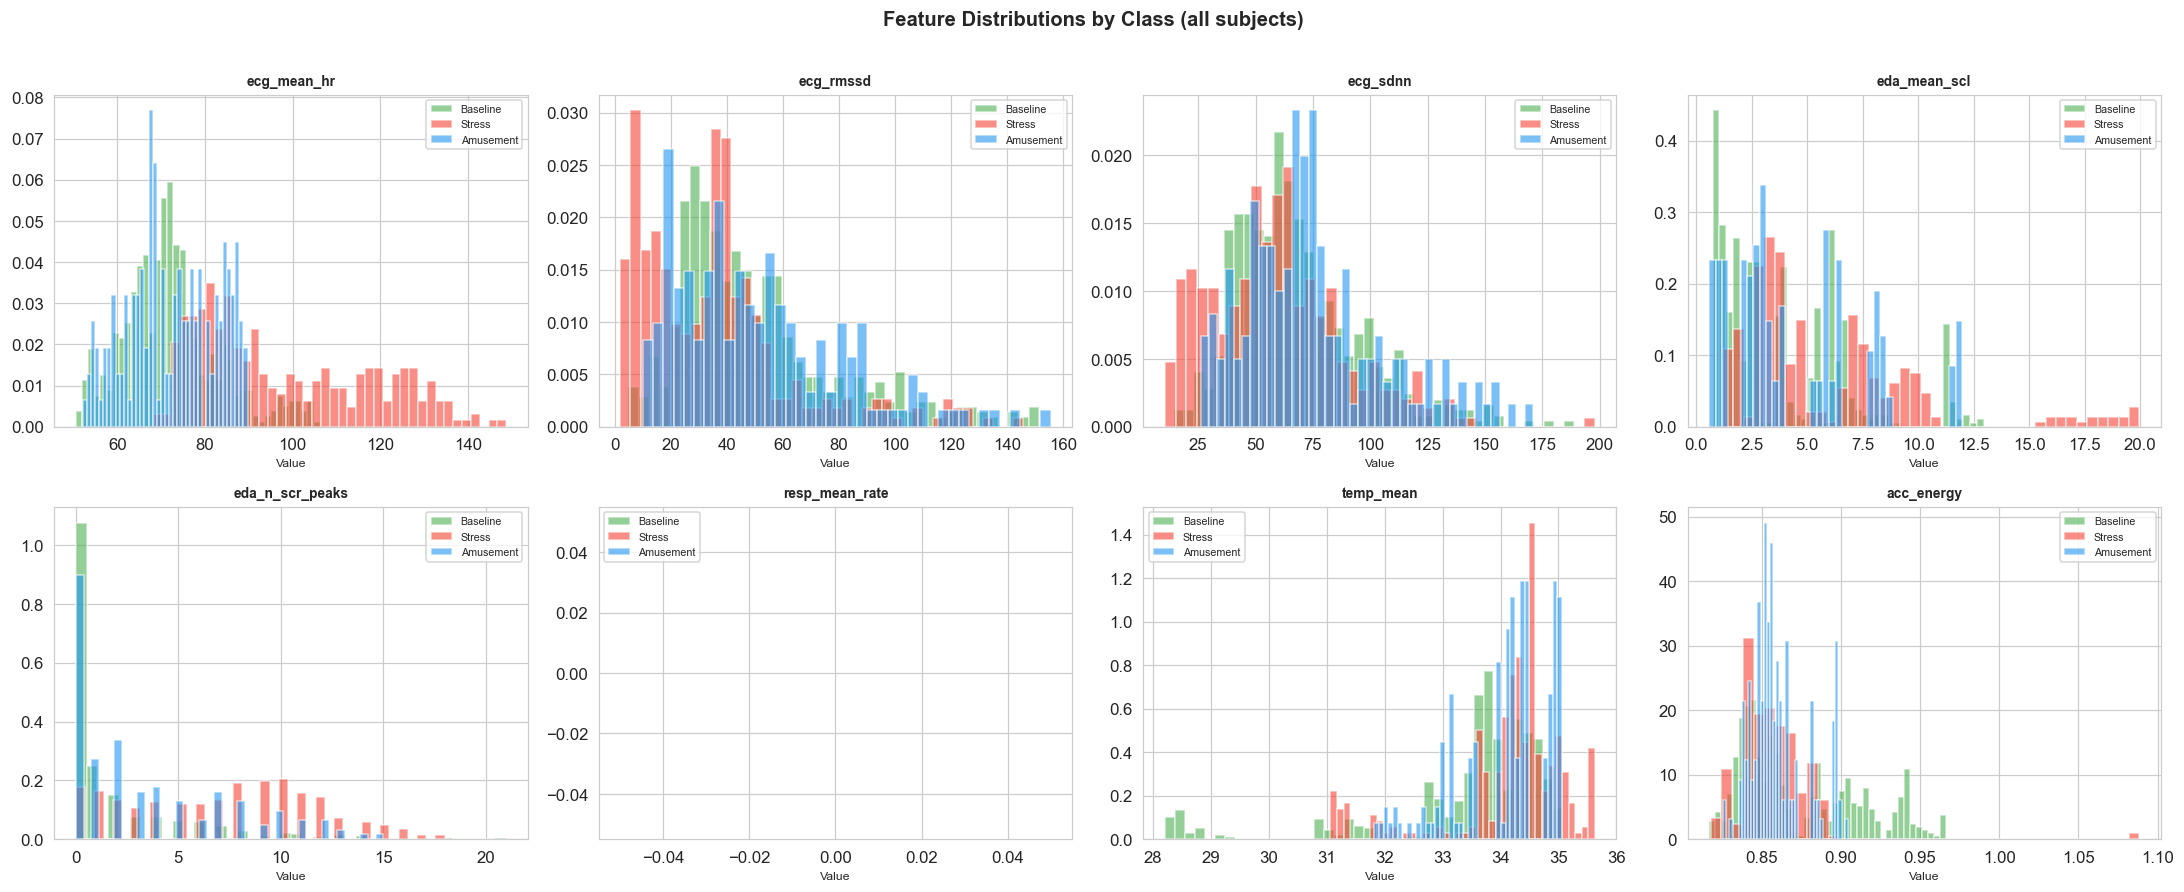

Saved: ..\results\plots\02_preprocessing\feature_distributions_by_class.png


In [13]:
# Plot distributions of key features across classes
key_features = [
    'ecg_mean_hr', 'ecg_rmssd', 'ecg_sdnn',
    'eda_mean_scl', 'eda_n_scr_peaks',
    'resp_mean_rate', 'temp_mean', 'acc_energy'
]
key_features = [f for f in key_features if f in df_binary.columns]

n_cols = 4
n_rows = int(np.ceil(len(key_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

colors = {0: '#4CAF50', 1: '#F44336', 2: '#2196F3'}
names  = {0: 'Baseline', 1: 'Stress', 2: 'Amusement'}

for i, feat in enumerate(key_features):
    ax = axes[i]
    for enc in sorted(df_3class['label_encoded'].unique()):
        vals = df_3class.loc[df_3class['label_encoded']==enc, feat].dropna()
        ax.hist(vals, bins=40, alpha=0.6,
                color=colors[enc], label=names[enc], density=True)
    ax.set_title(feat, fontweight='bold', fontsize=9)
    ax.set_xlabel('Value', fontsize=8)
    ax.legend(fontsize=7)

# Hide unused axes
for j in range(len(key_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Class (all subjects)',
             fontweight='bold', y=1.01)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'feature_distributions_by_class.png')
plt.savefig(p, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

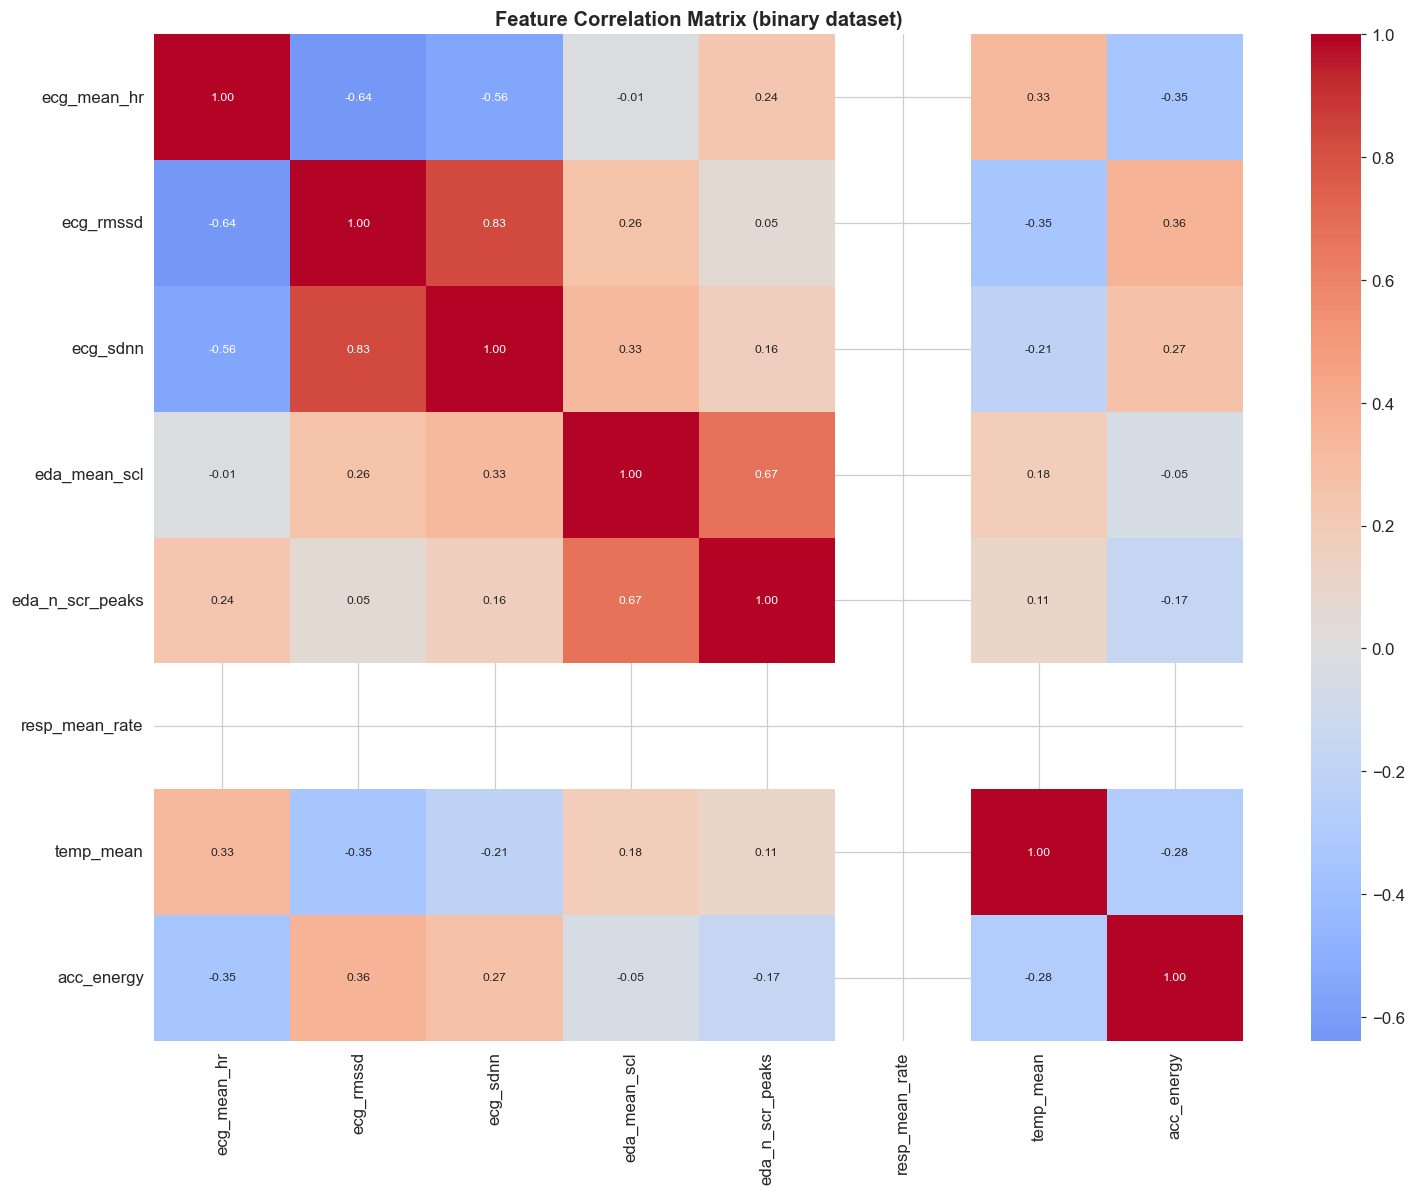

Saved: ..\results\plots\02_preprocessing\feature_correlation_heatmap.png


In [14]:
# Feature correlation heatmap
fig, ax = plt.subplots(figsize=(14, 11))
corr = df_binary[key_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix (binary dataset)',
             fontweight='bold')
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'feature_correlation_heatmap.png')
plt.savefig(p, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

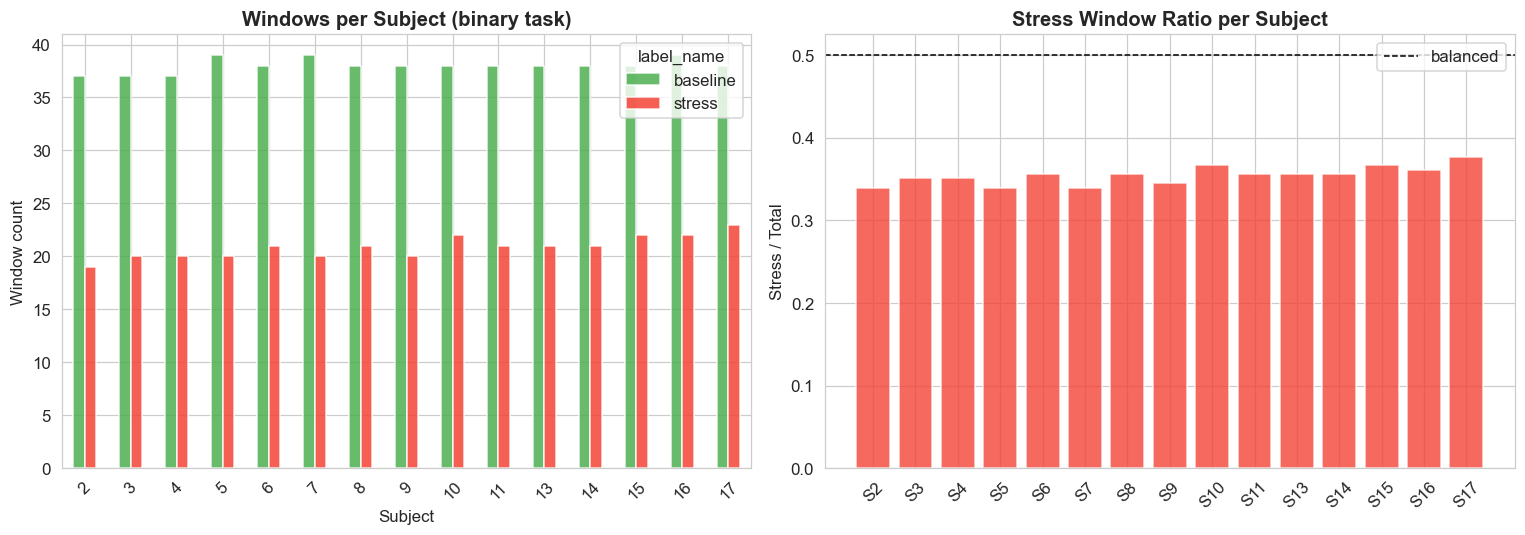

Saved: ..\results\plots\02_preprocessing\per_subject_window_counts.png


In [15]:
# Per-subject window counts (binary task)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Window counts
subj_counts = df_binary.groupby(['subject_id','label_name']).size().unstack(fill_value=0)
subj_counts.plot(kind='bar', ax=axes[0],
                 color=['#4CAF50','#F44336'], alpha=0.85)
axes[0].set_title('Windows per Subject (binary task)', fontweight='bold')
axes[0].set_xlabel('Subject')
axes[0].set_ylabel('Window count')
axes[0].tick_params(axis='x', rotation=45)

# Class balance per subject
subj_counts['stress_ratio'] = (
    subj_counts.get('stress', 0) /
    (subj_counts.get('baseline', 1) + subj_counts.get('stress', 0))
)
axes[1].bar(range(len(subj_counts)), subj_counts['stress_ratio'],
            color='#F44336', alpha=0.8)
axes[1].axhline(0.5, color='black', linestyle='--', lw=1, label='balanced')
axes[1].set_xticks(range(len(subj_counts)))
axes[1].set_xticklabels([f'S{s}' for s in subj_counts.index], rotation=45)
axes[1].set_title('Stress Window Ratio per Subject', fontweight='bold')
axes[1].set_ylabel('Stress / Total')
axes[1].legend()

plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'per_subject_window_counts.png')
plt.savefig(p, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

## 9. Save Datasets

In [16]:
# Save full raw feature matrix (all labels)
p_all = os.path.join(OUTPUT_DATA_DIR, 'wesad_features_all.csv')
df_all.to_csv(p_all, index=False)
print(f'Saved full feature matrix  : {p_all}')

# Save binary dataset
p_bin = os.path.join(OUTPUT_DATA_DIR, 'wesad_features_binary.csv')
df_binary.to_csv(p_bin, index=False)
print(f'Saved binary dataset       : {p_bin}')

# Save 3-class dataset
p_3cl = os.path.join(OUTPUT_DATA_DIR, 'wesad_features_3class.csv')
df_3class.to_csv(p_3cl, index=False)
print(f'Saved 3-class dataset      : {p_3cl}')

# Save feature column names (used by all subsequent notebooks)
feature_cols = [c for c in df_all.columns
                if c not in ['subject_id','label','label_encoded','label_name']]
p_feat = os.path.join(OUTPUT_DATA_DIR, 'feature_columns.json')
with open(p_feat, 'w') as f:
    json.dump(feature_cols, f, indent=2)
print(f'Saved feature column list  : {p_feat}')
print(f'\nTotal features: {len(feature_cols)}')
print(f'Features: {feature_cols}')

Saved full feature matrix  : ..\results\output_data\wesad_features_all.csv
Saved binary dataset       : ..\results\output_data\wesad_features_binary.csv
Saved 3-class dataset      : ..\results\output_data\wesad_features_3class.csv
Saved feature column list  : ..\results\output_data\feature_columns.json

Total features: 26
Features: ['ecg_mean_hr', 'ecg_sdnn', 'ecg_rmssd', 'ecg_pnn50', 'ecg_mean_rr', 'ecg_std_rr', 'eda_mean_scl', 'eda_std_scl', 'eda_mean_raw', 'eda_n_scr_peaks', 'eda_mean_scr_amp', 'resp_mean_rate', 'resp_std_rate', 'resp_mean_amp', 'resp_std_amp', 'temp_mean', 'temp_std', 'temp_delta', 'acc_mean', 'acc_std', 'acc_energy', 'acc_skew', 'acc_kurt', 'emg_mean_abs', 'emg_std', 'emg_rms']


## 10. Summary Log

In [17]:
label_dist_binary = {
    str(k): int(v) for k, v in
    Counter(df_binary['label_encoded']).items()
}
label_dist_3class = {
    str(k): int(v) for k, v in
    Counter(df_3class['label_encoded']).items()
}

summary = {
    'notebook'          : '02_wesad_preprocessing',
    'timestamp'         : datetime.now().isoformat(),
    'windowing': {
        'window_s'      : WINDOW_S,
        'step_s'        : STEP_S,
        'purity'        : PURITY,
        'window_samples': WIN_SAMP,
    },
    'subjects_processed': [int(s) for s in df_all['subject_id'].unique().tolist()],
    'subjects_failed'   : failed,
    'total_windows'     : int(len(df_all)),
    'n_features'        : len(feature_cols),
    'feature_names'     : feature_cols,
    'binary_task': {
        'total_windows' : int(len(df_binary)),
        'label_dist'    : label_dist_binary,
        'file'          : 'wesad_features_binary.csv'
    },
    '3class_task': {
        'total_windows' : int(len(df_3class)),
        'label_dist'    : label_dist_3class,
        'file'          : 'wesad_features_3class.csv'
    },
    'next'              : '03_dreamer_exploration.ipynb'
}

p = os.path.join(LOGS_DIR, '02_preprocessing_summary.json')
with open(p, 'w') as f:
    json.dump(summary, f, indent=2)

print('=' * 60)
print('PREPROCESSING COMPLETE')
print('=' * 60)
print(json.dumps(summary, indent=2))
print(f'\nLog saved: {p}')

PREPROCESSING COMPLETE
{
  "notebook": "02_wesad_preprocessing",
  "timestamp": "2026-05-09T16:26:51.190391",
  "windowing": {
    "window_s": 60,
    "step_s": 30,
    "purity": 0.8,
    "window_samples": 42000
  },
  "subjects_processed": [
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    13,
    14,
    15,
    16,
    17
  ],
  "subjects_failed": [],
  "total_windows": 1049,
  "n_features": 26,
  "feature_names": [
    "ecg_mean_hr",
    "ecg_sdnn",
    "ecg_rmssd",
    "ecg_pnn50",
    "ecg_mean_rr",
    "ecg_std_rr",
    "eda_mean_scl",
    "eda_std_scl",
    "eda_mean_raw",
    "eda_n_scr_peaks",
    "eda_mean_scr_amp",
    "resp_mean_rate",
    "resp_std_rate",
    "resp_mean_amp",
    "resp_std_amp",
    "temp_mean",
    "temp_std",
    "temp_delta",
    "acc_mean",
    "acc_std",
    "acc_energy",
    "acc_skew",
    "acc_kurt",
    "emg_mean_abs",
    "emg_std",
    "emg_rms"
  ],
  "binary_task": {
    "total_windows": 883,
    "label_dist": {
   